In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# Drop useless columns
df = df.drop(["UDI", "Product ID"], axis=1)

# Encode categorical
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

# Feature Fusion
df["Temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]

# Improved features
df["Torque_per_speed"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
df["Wear_rate"] = df["Tool wear [min]"] / (df["Rotational speed [rpm]"] + 1)

# Failure type (innovation)
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df["Failure Type"] = df[failure_cols].idxmax(axis=1)

# Split
X = df.drop(["Machine failure", "Failure Type"] + failure_cols, axis=1)
y = df["Machine failure"]

feature_names = X.columns

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

scaler = StandardScaler()
X_resampled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_resampled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['Recall']
)

model.fit(
    X_resampled, y_resampled,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - Recall: 0.7632 - loss: 0.3910 - val_Recall: 0.8380 - val_loss: 0.3603
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8320 - loss: 0.2945 - val_Recall: 0.8794 - val_loss: 0.2981
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8594 - loss: 0.2679 - val_Recall: 0.8580 - val_loss: 0.3368
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8555 - loss: 0.2553 - val_Recall: 0.8978 - val_loss: 0.2708
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8700 - loss: 0.2437 - val_Recall: 0.8878 - val_loss: 0.2874
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8764 - loss: 0.2346 - val_Recall: 0.8997 - val_loss: 0.2511
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8764 - loss: 0.2256 - val_Recall: 0.9049 - val_loss: 0.2413
Epoch 8/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8801 - loss: 0.2214 - val_Recall: 0.8929 - val_loss: 0.2601
Epoch 9/20
387/387 

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import numpy as np

input_dim = X_resampled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# Train on NORMAL data only
X_normal = X_resampled[y_resampled == 0]

autoencoder.fit(
    X_normal, X_normal,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Reconstruction error
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean((X_test_scaled - reconstructions) ** 2, axis=1)

# use only NORMAL data to set threshold
recon_train = autoencoder.predict(X_resampled[y_resampled == 0], verbose=0)
train_mse = np.mean((X_resampled[y_resampled == 0] - recon_train)**2, axis=1)

anomaly_threshold = np.percentile(train_mse, 99)
anomaly_flags = (mse > anomaly_threshold).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
prob = model.predict(X_test_scaled).flatten()

threshold = 0.3
y_pred = (prob > threshold).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
def get_root_cause(sample_scaled, model, top_k=2):
    baseline = model.predict(sample_scaled)[0][0]

    importances = []

    for i in range(sample_scaled.shape[1]):
        modified = sample_scaled.copy()
        modified[0][i] = 0

        new_pred = model.predict(modified)[0][0]
        impact = abs(baseline - new_pred)

        importances.append((feature_names[i], impact))

    importances.sort(key=lambda x: x[1], reverse=True)
    return importances[:top_k]

In [ ]:
def risk_level(score):
    if score > 0.7:
        return "HIGH"
    elif score > 0.4:
        return "MEDIUM"
    else:
        return "LOW"

def confidence_level(p):
    if abs(p - 0.5) < 0.1:
        return "UNCERTAIN"
    elif p > 0.8 or p < 0.2:
        return "HIGH CONFIDENCE"
    else:
        return "MODERATE"

In [ ]:
def maintenance_action(pred, anomaly, causes, sample):

    if pred == 1:
        top_feature = causes[0][0]

        if "Tool wear" in top_feature:
            return "🔧 Replace tool (high wear)"

        elif "Torque" in top_feature:
            return "⚠️ Check motor load"

        elif "temperature" in top_feature.lower():
            return "🌡️ Inspect cooling system"

        elif anomaly == -1:
            return "🚨 Unexpected anomaly → full inspection"

        else:
            return "🛠 Preventive maintenance"

    return "✅ Normal operation"

In [ ]:
import time

print("------ ADVANCED MONITORING SYSTEM ------")

for i in range(5):
    sample = X_test.iloc[i]
    sample_scaled = scaler.transform([sample])

    prob_val = model.predict(sample_scaled)[0][0]
    pred = int(prob_val > threshold)

    # Autoencoder anomaly
    recon = autoencoder.predict(sample_scaled)
    mse_val = np.mean((sample_scaled - recon)**2)
    anomaly = -1 if mse_val > anomaly_threshold else 1

    # Root cause
    causes = get_root_cause(sample_scaled, model)

    # Fusion score
    normalized_mse = min(mse_val / anomaly_threshold, 1)
    final_score = 0.7 * prob_val + 0.3 * normalized_mse

    risk = risk_level(final_score)
    confidence = confidence_level(prob_val)

    action = maintenance_action(pred, anomaly, causes, sample)

    print("\nMachine", i)
    print("Prediction:", "FAILURE" if pred else "NORMAL")
    print("Risk Level:", risk)
    print("Confidence:", confidence)
    print("Anomaly:", "YES" if anomaly == -1 else "NO")
    print("Root Causes:", causes)
    print("Action:", action)

    time.sleep(1)

------ ADVANCED MONITORING SYSTEM ------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

Machine 0
Prediction: FAILURE
Risk Level: HIGH
Confidence: HIGH CONFIDENCE
Anomaly: NO
Root Causes: [('Torque_per_speed', np.float32(0.96737874)), ('Torque [Nm]', np.float32(0.36573684))]
Action: ⚠️ Check motor load


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Machine 1
Prediction: NORMAL
Risk Level: LOW
Confidence: HIGH CONFIDENCE
Anomaly: NO
Root Causes: [('Torque_per_speed', np.float32(0.25993052)), ('Process temperature [K]', np.float32(0.05177436))]
Action: ✅ Normal operation
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Machine 2
Prediction: FAILURE
Risk Level: LOW
Confidence: MODERATE
Anomaly: NO
Root Causes: [('Torque_per_speed', np.float32(0.32049072)), ('Wear_rate', np.float32(0.29153925))]
Action: ⚠️ Check motor load
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Machine 3
Prediction: NORMAL
Risk Level: LOW
Confidence: HIGH CONFIDENCE
Anomaly: NO
Root Causes: [('Process temperature [K]', np.float32(0.0040614437)), ('Air temperature [K]', np.float32(0.0010159475))]
Action: ✅ Normal operation
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Machine 4
Prediction: NORMAL
Risk Level: LOW
Confidence: HIGH CONFIDENCE
Anomaly: NO
Root Causes: [('Rotational speed [rpm]', np.float32(0.8277702)), ('Type', np.float32(0.60882944))]
Action: ✅ Normal operation


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

print("\nMissed Failures:", ((y_test == 1) & (y_pred == 0)).sum())

Accuracy: 0.9
Recall: 0.9411764705882353

Confusion Matrix:
 [[1736  196]
 [   4   64]]

Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95      1932
           1       0.25      0.94      0.39        68

    accuracy                           0.90      2000
   macro avg       0.62      0.92      0.67      2000
weighted avg       0.97      0.90      0.93      2000


Missed Failures: 4


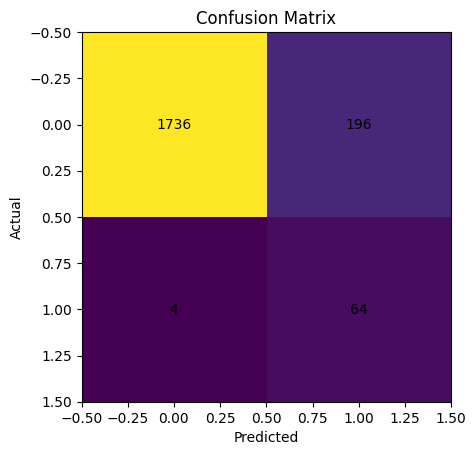

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

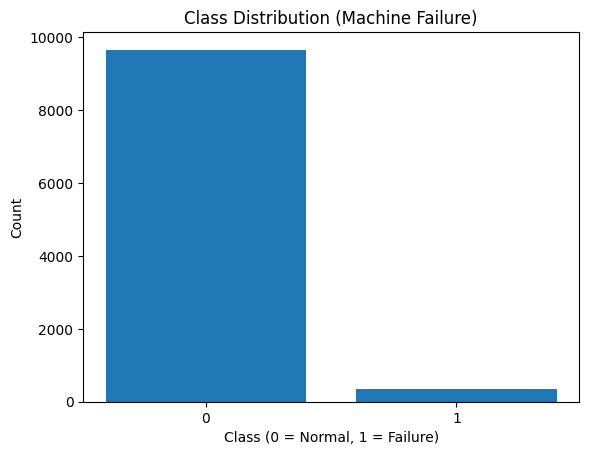

In [ ]:
import matplotlib.pyplot as plt

counts = y.value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution (Machine Failure)")
plt.xlabel("Class (0 = Normal, 1 = Failure)")
plt.ylabel("Count")
plt.show()

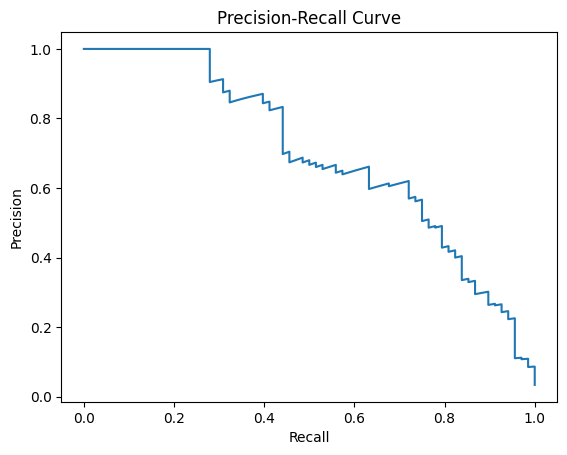

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, prob)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

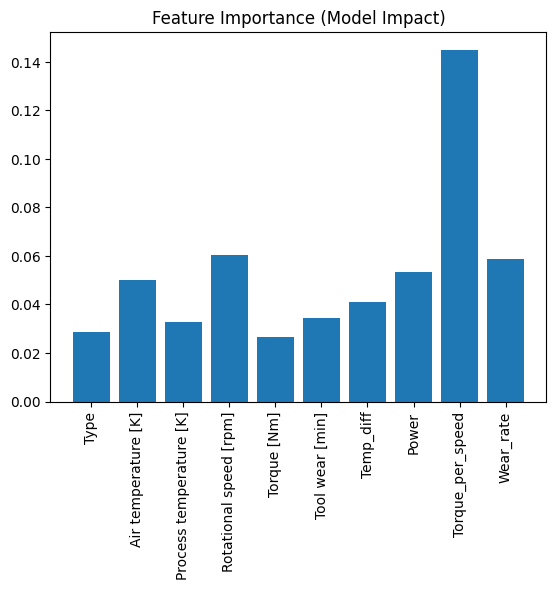

In [ ]:
feature_means = np.mean(X_resampled, axis=0)

importance_scores = []

base_pred = model.predict(X_test_scaled, verbose=0).flatten()

for i in range(X_test_scaled.shape[1]):
    modified = X_test_scaled.copy()
    modified[:, i] = feature_means[i]  # use mean instead of 0

    new_pred = model.predict(modified, verbose=0).flatten()

    impact = np.mean(np.abs(base_pred - new_pred))
    importance_scores.append(impact)

plt.figure()
plt.bar(range(len(feature_names)), importance_scores)
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.title("Feature Importance (Model Impact)")
plt.show()

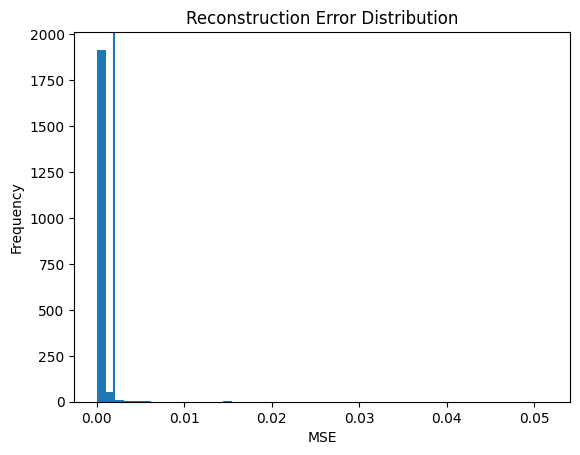

In [ ]:
plt.figure()
plt.hist(mse, bins=50)
plt.axvline(anomaly_threshold)
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.show()

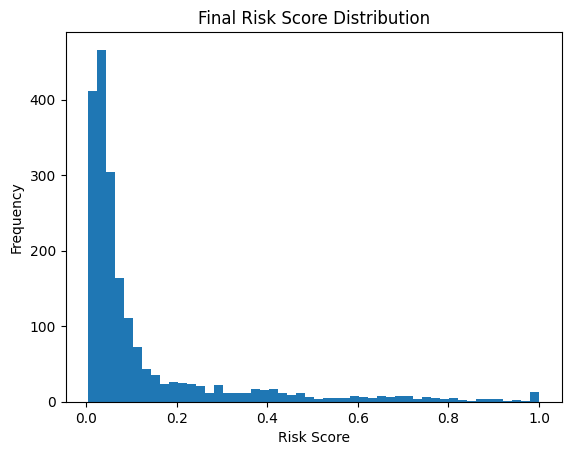

In [ ]:
final_scores = 0.7 * prob + 0.3 * np.minimum(mse / anomaly_threshold, 1)

plt.figure()
plt.hist(final_scores, bins=50)
plt.title("Final Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

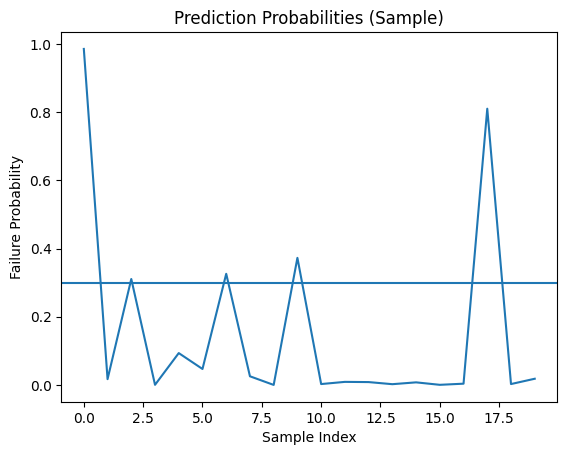

In [ ]:
sample_probs = prob[:20]

plt.figure()
plt.plot(sample_probs)
plt.axhline(0.3)
plt.title("Prediction Probabilities (Sample)")
plt.xlabel("Sample Index")
plt.ylabel("Failure Probability")
plt.show()